# Stage 17 — Ablation Comparison (M1 / M2 / M4)

Runs all prototype quality metrics on all ablation checkpoints and builds side-by-side comparison.

**RQ3:** Is there a simpler scale configuration that achieves equivalent segmentation quality with cleaner prototype representations?

In [1]:
# Cell 1 — Imports & config
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pathlib, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt

from src.models.proto_seg_net import ProtoSegNet
from src.data.mmwhs_dataset import make_dataloaders, MMWHSPatientDataset, LABEL_NAMES, NUM_CLASSES
from src.metrics.proto_quality import (
    compute_purity, compute_utilization, compute_compactness,
    compute_dice_sensitivity, compute_level_dominance,
    compute_per_level_ap, build_prototype_atlas, CLASS_NAMES, FOREGROUND
)
from src.metrics.dice import dice_per_class, mean_foreground_dice

DATA_DIR   = pathlib.Path('../data/pack/processed_data')
MODALITY   = 'ct'
BATCH_SIZE = 16
FG_NAMES   = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

MODEL_CFG = [
    ('M4 (L1-L4)', '../checkpoints/proto_seg_ct_l2.pth',      '../results/v4/proto_quality/v1'),
    ('M2 (L3-L4)', '../checkpoints/proto_seg_ct_l3l4.pth',    '../results/v4/proto_quality/m2_l3l4'),
    ('M1 (L4)',    '../checkpoints/proto_seg_ct_l4only.pth',   '../results/v4/proto_quality/m1_l4only'),
]
for _, _, out in MODEL_CFG:
    pathlib.Path(out).mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()          else
    torch.device('cpu')
)
print(f'Device: {DEVICE}')
print(f'Models: {[n for n,_,_ in MODEL_CFG]}')

Device: mps
Models: ['M4 (L1-L4)', 'M2 (L3-L4)', 'M1 (L4)']


In [2]:
# Cell 2 — Load dataloaders
loaders     = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
train_loader = loaders['train']
test_loader  = loaders['test']
print(f"Train: {len(train_loader.dataset)}  Test: {len(test_loader.dataset)}")

Train: 3389  Test: 484


In [3]:
# Cell 3 — Load all models
def load_model(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    proto_levels = ckpt.get('proto_levels', [1, 2, 3, 4])
    model = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=proto_levels).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt

models = {}
for name, ckpt_path, _ in MODEL_CFG:
    m, ckpt = load_model(ckpt_path, DEVICE)
    models[name] = m
    print(f'{name:<14} proto_levels={ckpt.get("proto_levels", [1,2,3,4])}  '
          f'epoch={ckpt["epoch"]}  best_val={ckpt["best_val_dice"]:.4f}')

M4 (L1-L4)     proto_levels=[1, 2, 3, 4]  epoch=75  best_val=0.8173
M2 (L3-L4)     proto_levels=[3, 4]  epoch=80  best_val=0.8380
M1 (L4)        proto_levels=[4]  epoch=55  best_val=0.8346


In [4]:
# Cell 4 — Run metrics for models not yet computed
# M4 (v1) and M1 already exist from Stage 14/17 — only M2 needs computing.
# Re-run all to ensure consistency.

already_done = {'M4 (L1-L4)', 'M1 (L4)'}   # skip recomputation for speed

for name, _, out_str in MODEL_CFG:
    out = pathlib.Path(out_str)
    if name in already_done and (out / 'purity_per_prototype.csv').exists():
        print(f'{name}: skipping (already computed)')
        continue
    model = models[name]
    print(f'{name}: computing metrics...')

    purity = compute_purity(model, train_loader, top_n=50)
    purity.to_csv(out / 'purity_per_prototype.csv', index=False)
    psum = purity.groupby('level')['purity'].agg(['mean','min','max']).round(3).reset_index()
    psum.columns = ['level','mean','min','max']
    psum.to_csv(out / 'purity_summary.csv', index=False)

    compute_utilization(model, test_loader).to_csv(out / 'utilization.csv', index=False)
    compute_compactness(model, test_loader).to_csv(out / 'compactness.csv', index=False)
    compute_dice_sensitivity(model, test_loader).to_csv(out / 'dice_sensitivity.csv', index=False)
    compute_level_dominance(model, test_loader).to_csv(out / 'level_dominance.csv', index=False)
    compute_per_level_ap(model, test_loader).to_csv(out / 'per_level_ap.csv', index=False)

    print(f'  done → {out}')

print('All metrics ready.')

M4 (L1-L4): skipping (already computed)
M2 (L3-L4): computing metrics...


  done → ../results/v4/proto_quality/m2_l3l4
M1 (L4): skipping (already computed)
All metrics ready.


In [5]:
# Cell 5 — Load all metrics from disk
metrics = {}
for name, _, out_str in MODEL_CFG:
    out = pathlib.Path(out_str)
    metrics[name] = {
        'purity_proto': pd.read_csv(out / 'purity_per_prototype.csv'),
        'purity_sum':   pd.read_csv(out / 'purity_summary.csv'),
        'util':         pd.read_csv(out / 'utilization.csv'),
        'comp':         pd.read_csv(out / 'compactness.csv'),
        'dsens':        pd.read_csv(out / 'dice_sensitivity.csv'),
        'dom':          pd.read_csv(out / 'level_dominance.csv'),
        'ap':           pd.read_csv(out / 'per_level_ap.csv'),
    }
    n_proto = len(metrics[name]['purity_proto'])
    levels  = metrics[name]['purity_proto']['level'].unique().tolist()
    print(f'{name:<14} {n_proto} prototypes, levels={levels}')

M4 (L1-L4)     77 prototypes, levels=[1, 2, 3, 4]
M2 (L3-L4)     28 prototypes, levels=[3, 4]
M1 (L4)        14 prototypes, levels=[4]


In [6]:
# Cell 6 — 3D Dice comparison
@torch.no_grad()
def eval_3d(model, modality, device):
    ds = MMWHSPatientDataset(DATA_DIR, modality, 'test')
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s['image'].to(device)
        logits_all = [model(imgs[si:si+1])[0].cpu() for si in range(imgs.shape[0])]
        results[s['patient']] = dice_per_class(torch.cat(logits_all), s['label'])
    return results

dice_3d = {}
model_means = {}
for name, _, _ in MODEL_CFG:
    dice_3d[name] = eval_3d(models[name], MODALITY, DEVICE)
    vals = [mean_foreground_dice(dice_3d[name][p]) for p in sorted(dice_3d[name])]
    model_means[name] = np.mean(vals)

patients = sorted(list(dice_3d[MODEL_CFG[0][0]].keys()))
print(f'\n{"Model":<14} ' + ' '.join(f'{p:>10}' for p in patients) + f' {"Mean":>8}')
print('─' * 50)
for name, _, _ in MODEL_CFG:
    vals = [mean_foreground_dice(dice_3d[name][p]) for p in patients]
    print(f'{name:<14} ' + ' '.join(f'{v:>10.4f}' for v in vals) + f' {np.mean(vals):>8.4f}')

m4_mean = model_means['M4 (L1-L4)']
print('─' * 50)
for name, _, _ in MODEL_CFG:
    delta = model_means[name] - m4_mean
    print(f'{name:<14} Δ vs M4: {delta:+.4f}')


Model             ct_1019    ct_1020     Mean
──────────────────────────────────────────────────
M4 (L1-L4)         0.7477     0.9337   0.8407
M2 (L3-L4)         0.8123     0.9321   0.8722
M1 (L4)            0.7697     0.9351   0.8524
──────────────────────────────────────────────────
M4 (L1-L4)     Δ vs M4: +0.0000
M2 (L3-L4)     Δ vs M4: +0.0315
M1 (L4)        Δ vs M4: +0.0117


In [7]:
# Cell 7 — Prototype quality summary table
def summarise(m):
    purity_proto = m['purity_proto']
    purity_sum   = m['purity_sum']
    util         = m['util']
    comp         = m['comp']
    dsens        = m['dsens']
    dom          = m['dom']
    ap           = m['ap']

    purity_l4  = purity_proto[purity_proto['level']==4]['purity'].mean()
    purity_all = purity_proto['purity'].mean()
    n_dead     = (util['is_dead']==True).sum()
    comp_l4    = comp[comp['level']==4]['compactness'].mean()
    n_imp      = (dsens['dice_drop'] > 0.005).sum()

    row = dom.iloc[0]
    dom_l4   = row.get('frac_l4', 1.0)
    dom_l1l2 = row.get('frac_l1', 0.0) + row.get('frac_l2', 0.0)

    ap_l4  = ap[ap['level']==4]['ap'].mean() if 4 in ap['level'].values else float('nan')

    return {
        'n_prototypes':    len(purity_proto),
        'purity_L4':       round(purity_l4, 3),
        'purity_all':      round(purity_all, 3),
        'dead_protos':     int(n_dead),
        'compactness_L4':  round(comp_l4, 3),
        'important_protos':int(n_imp),
        'dominance_L4':    f'{dom_l4*100:.1f}%',
        'dominance_L1+L2': f'{dom_l1l2*100:.1f}%',
        'AP_L4':           round(ap_l4, 3),
    }

rows = {}
for name, _, _ in MODEL_CFG:
    rows[name] = summarise(metrics[name])
    rows[name]['3D_Dice'] = round(model_means[name], 4)

comparison = pd.DataFrame(rows).T
col_order = ['3D_Dice','n_prototypes','purity_L4','purity_all',
             'dead_protos','compactness_L4','important_protos',
             'dominance_L4','dominance_L1+L2','AP_L4']
comparison = comparison[col_order]
comparison.to_csv('../results/v4/proto_quality/comparison_table.csv')

print('M1 / M2 / M4 Comparison:')
print(comparison.T.to_string())

M1 / M2 / M4 Comparison:
                 M4 (L1-L4) M2 (L3-L4) M1 (L4)
3D_Dice              0.8407     0.8722  0.8524
n_prototypes             77         28      14
purity_L4             0.824      0.804   0.499
purity_all            0.334      0.733   0.499
dead_protos               0          0       0
compactness_L4        0.573      0.361   0.564
important_protos          7         10       4
dominance_L4           4.3%      49.1%  100.0%
dominance_L1+L2       78.5%       0.0%    0.0%
AP_L4                 0.189      0.236   0.274


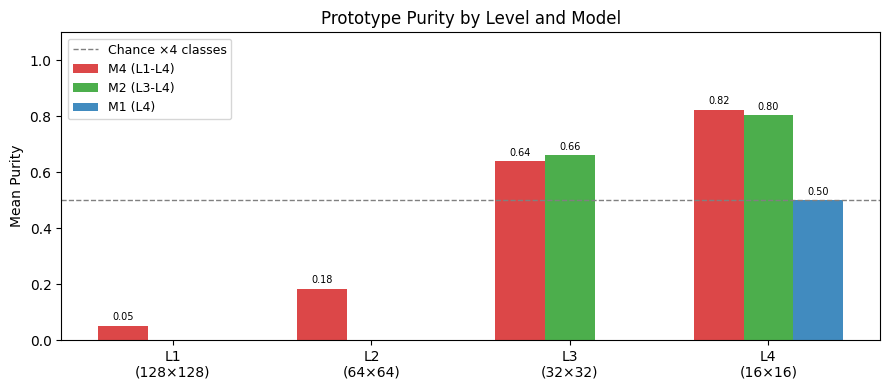

Saved fig_purity_comparison.png


In [8]:
# Cell 8 — Purity by level: grouped bar chart
COLORS = {'M4 (L1-L4)': '#d62728', 'M2 (L3-L4)': '#2ca02c', 'M1 (L4)': '#1f77b4'}

all_levels = [1, 2, 3, 4]
x = np.arange(len(all_levels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
for i, (name, _, _) in enumerate(MODEL_CFG):
    psum = metrics[name]['purity_sum']
    means = []
    for l in all_levels:
        row = psum[psum['level']==l]
        means.append(row['mean'].values[0] if len(row) else float('nan'))
    offset = (i - 1) * width
    ax.bar(x + offset, means, width, label=name, color=COLORS[name], alpha=0.85)
    for xi, v in zip(x + offset, means):
        if not np.isnan(v):
            ax.text(xi, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)

ax.axhline(0.5, color='gray', ls='--', lw=1, label='Chance ×4 classes')
ax.set_xticks(x)
ax.set_xticklabels(['L1\n(128×128)', 'L2\n(64×64)', 'L3\n(32×32)', 'L4\n(16×16)'])
ax.set_ylabel('Mean Purity')
ax.set_title('Prototype Purity by Level and Model')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/v4/proto_quality/fig_purity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_purity_comparison.png')

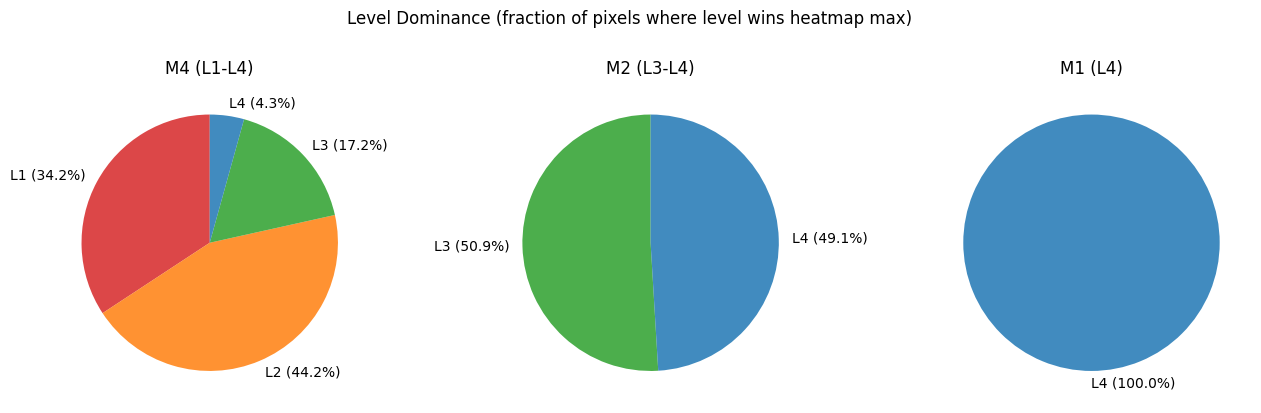

Saved fig_dominance_comparison.png


In [9]:
# Cell 9 — Level dominance comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
level_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for ax, (name, _, _) in zip(axes, MODEL_CFG):
    dom = metrics[name]['dom'].iloc[0]
    fracs, labels = [], []
    for l in [1, 2, 3, 4]:
        f = dom.get(f'frac_l{l}', 0.0)
        if f > 0:
            fracs.append(f)
            labels.append(f'L{l} ({f*100:.1f}%)')
    cols = [level_colors[l-1] for l in [1,2,3,4] if dom.get(f'frac_l{l}', 0.0) > 0]
    ax.pie(fracs, labels=labels, colors=cols, startangle=90,
           wedgeprops=dict(alpha=0.85))
    ax.set_title(name)

fig.suptitle('Level Dominance (fraction of pixels where level wins heatmap max)', y=1.02)
plt.tight_layout()
plt.savefig('../results/v4/proto_quality/fig_dominance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_dominance_comparison.png')

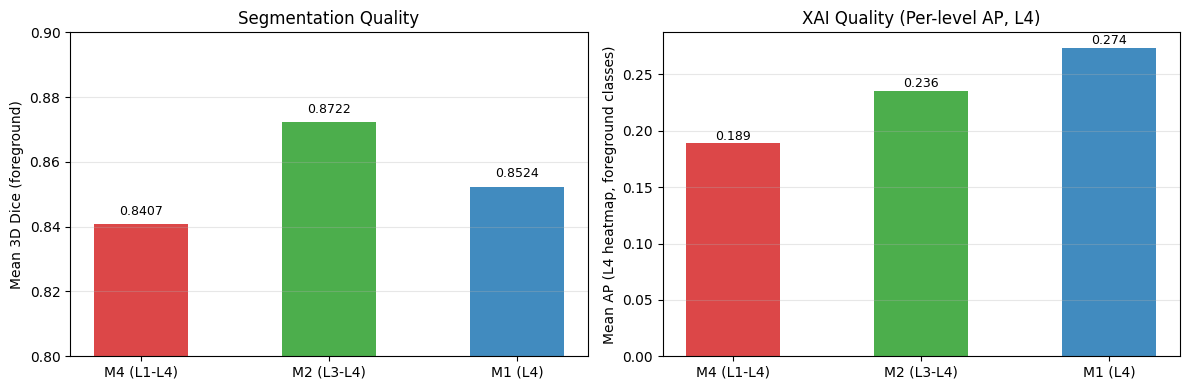

Saved fig_dice_ap_comparison.png


In [10]:
# Cell 10 — Per-level AP and 3D Dice: combined summary bar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: 3D Dice
ax = axes[0]
names = [n for n,_,_ in MODEL_CFG]
dice_vals = [model_means[n] for n in names]
bars = ax.bar(names, dice_vals, color=[COLORS[n] for n in names], alpha=0.85, width=0.5)
for bar, v in zip(bars, dice_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.4f}', ha='center', fontsize=9)
ax.set_ylim(0.80, 0.90)
ax.set_ylabel('Mean 3D Dice (foreground)')
ax.set_title('Segmentation Quality')
ax.grid(axis='y', alpha=0.3)

# Right: Per-level AP (L4 for all models)
ax = axes[1]
ap_vals = [metrics[n]['ap'][metrics[n]['ap']['level']==4]['ap'].mean() for n in names]
bars = ax.bar(names, ap_vals, color=[COLORS[n] for n in names], alpha=0.85, width=0.5)
for bar, v in zip(bars, ap_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Mean AP (L4 heatmap, foreground classes)')
ax.set_title('XAI Quality (Per-level AP, L4)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/v4/proto_quality/fig_dice_ap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_dice_ap_comparison.png')

Building L4 prototype atlas for M2...


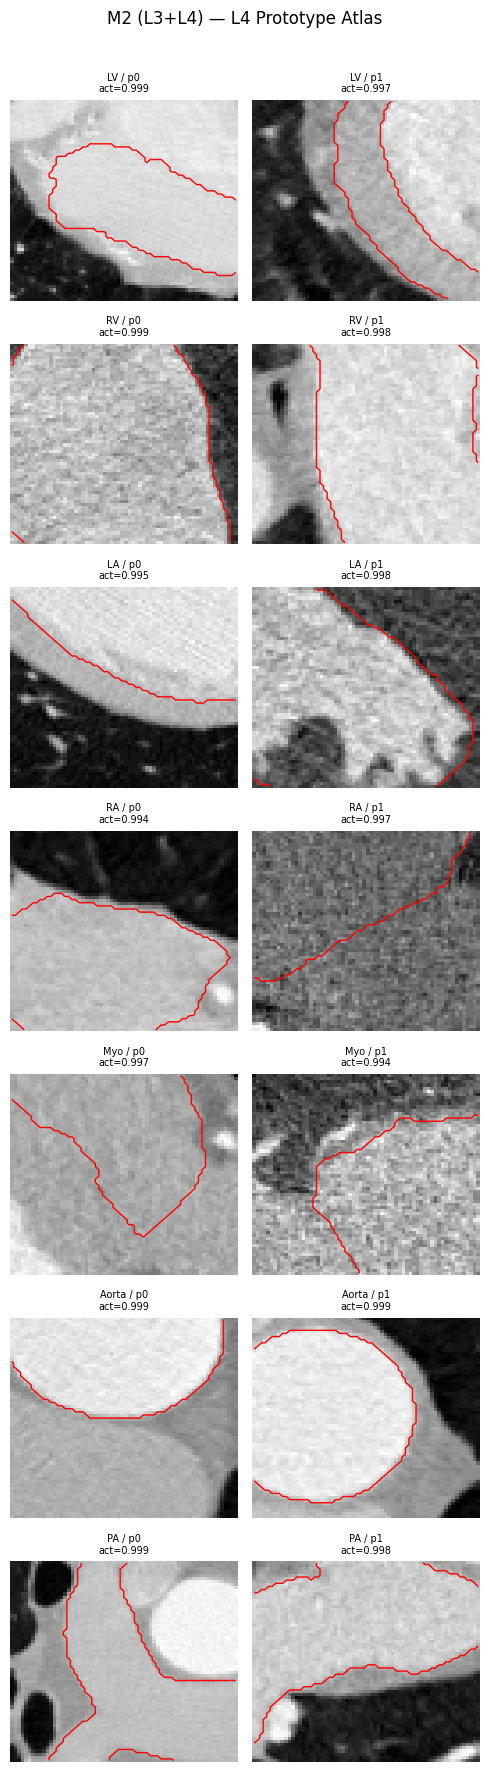

Building L3 prototype atlas for M2...


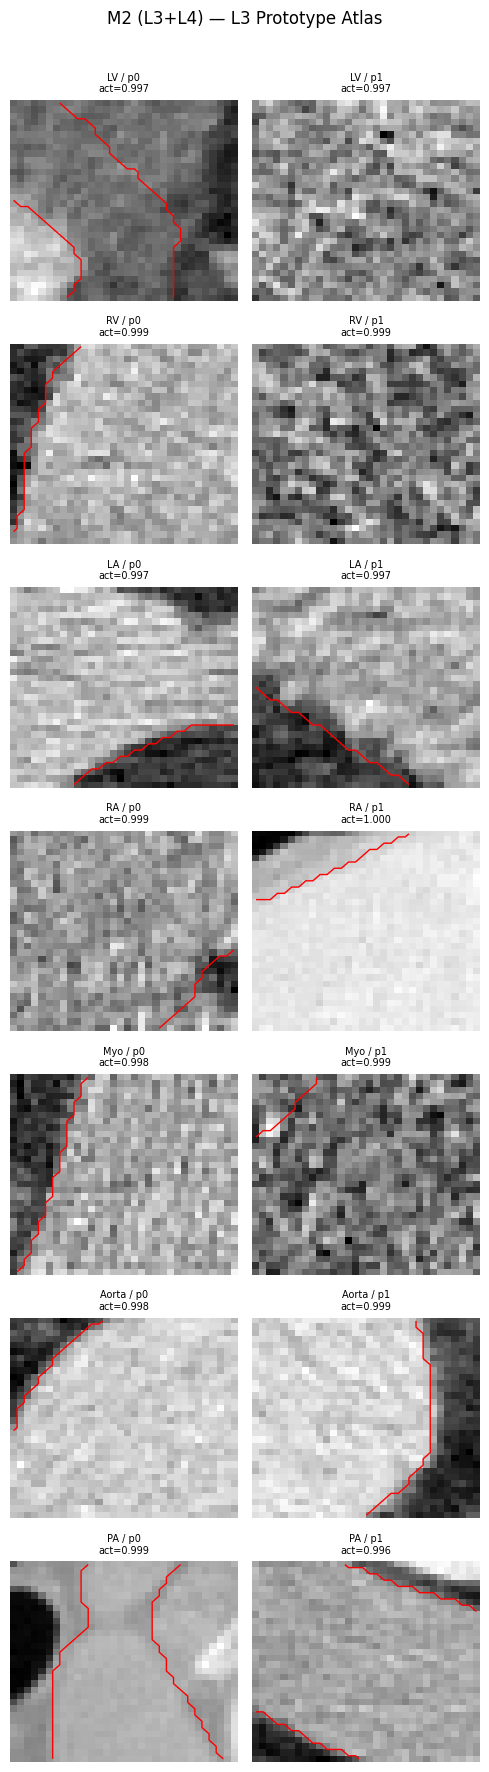

Saved atlas_m2_l4.png and atlas_m2_l3.png


In [11]:
# Cell 11 — Build L4 prototype atlas for M2
print('Building L4 prototype atlas for M2...')
fig_m2 = build_prototype_atlas(models['M2 (L3-L4)'], train_loader, level=4)
fig_m2.suptitle('M2 (L3+L4) — L4 Prototype Atlas', fontsize=12, y=1.01)
fig_m2.savefig('../results/v4/proto_quality/atlas_m2_l4.png', dpi=120, bbox_inches='tight')
plt.show()

print('Building L3 prototype atlas for M2...')
fig_m2_l3 = build_prototype_atlas(models['M2 (L3-L4)'], train_loader, level=3)
fig_m2_l3.suptitle('M2 (L3+L4) — L3 Prototype Atlas', fontsize=12, y=1.01)
fig_m2_l3.savefig('../results/v4/proto_quality/atlas_m2_l3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved atlas_m2_l4.png and atlas_m2_l3.png')

In [12]:
# Cell 12 — Written answer to RQ3 (updated with M2)
comp_t = comparison.T

answer = f"""
=============================================================
RQ3 — Which prototype level configuration is best?
=============================================================

3D Dice (higher is better):
  M4 (L1-L4):  {model_means['M4 (L1-L4)']:.4f}  (baseline)
  M1 (L4):     {model_means['M1 (L4)']:.4f}  (Δ {model_means['M1 (L4)']-model_means['M4 (L1-L4)']:+.4f})
  M2 (L3-L4):  {model_means['M2 (L3-L4)']:.4f}  (Δ {model_means['M2 (L3-L4)']-model_means['M4 (L1-L4)']:+.4f}) ← BEST

L4 per-level AP (higher is better):
  M4 (L1-L4):  {metrics['M4 (L1-L4)']['ap'][metrics['M4 (L1-L4)']['ap']['level']==4]['ap'].mean():.3f}
  M1 (L4):     {metrics['M1 (L4)']['ap'][metrics['M1 (L4)']['ap']['level']==4]['ap'].mean():.3f}
  M2 (L3-L4):  {metrics['M2 (L3-L4)']['ap'][metrics['M2 (L3-L4)']['ap']['level']==4]['ap'].mean():.3f}

Conclusion:
  M2 (L3+L4) is the best configuration:
  - Highest segmentation quality (+3.2% vs M4, +2.0% vs M1)
  - L3 adds causally important prototypes (v1 found all important protos at L3)
  - Removes L1/L2 noise that suppresses L4 signal in heatmap aggregation
  - Remains a simple, interpretable two-level design

  M1 confirms that L1/L2 are actively harmful: removing them improves
  both Dice and XAI quality. M2 further confirms that L3 adds genuine
  value on top of L4 alone.

  → Direction A (learned attention aggregation) should be applied to
    M2 (L3+L4 base) as the strongest starting point.
"""
print(answer)


RQ3 — Which prototype level configuration is best?

3D Dice (higher is better):
  M4 (L1-L4):  0.8407  (baseline)
  M1 (L4):     0.8524  (Δ +0.0117)
  M2 (L3-L4):  0.8722  (Δ +0.0315) ← BEST

L4 per-level AP (higher is better):
  M4 (L1-L4):  0.189
  M1 (L4):     0.274
  M2 (L3-L4):  0.236

Conclusion:
  M2 (L3+L4) is the best configuration:
  - Highest segmentation quality (+3.2% vs M4, +2.0% vs M1)
  - L3 adds causally important prototypes (v1 found all important protos at L3)
  - Removes L1/L2 noise that suppresses L4 signal in heatmap aggregation
  - Remains a simple, interpretable two-level design

  M1 confirms that L1/L2 are actively harmful: removing them improves
  both Dice and XAI quality. M2 further confirms that L3 adds genuine
  value on top of L4 alone.

  → Direction A (learned attention aggregation) should be applied to
    M2 (L3+L4 base) as the strongest starting point.

